<img src="../pic/CU.png" style="width: 100%; display: block; margin: auto;">

# Курс по прогнозированию временных рядов
# Неделя 5.
# Регрессоры в SARIMAX: где их взять на будущее

В ноутбуке `04` мы закончили на неприятном месте. Модель с `exog` обучается
прекрасно, а на попытке построить прогноз падает:

> `ValueError: Out-of-sample operations in a model with a regression component
> require additional exogenous values via the exog argument.`

Перевод: «я умею считать $\hat y_{T+h} = \beta' x_{T+h} + \hat n_{T+h}$, но
$x_{T+h}$ у меня нет — дайте». И вот здесь у большинства внедрений SARIMAX
всё и заканчивается: в обучающей выборке регрессор был, а в будущем его нет,
потому что будущего ещё не случилось.

Хорошая новость: **вариантов, откуда взять $x_{T+1..T+h}$, ровно шесть**, и они
сильно отличаются по надёжности. Плохая новость: разница между «регрессор
известен точно» и «регрессор мы тоже спрогнозировали» в коде не видна вообще —
`forecast()` в обоих случаях вернёт красивую линию с узким интервалом.

## Шесть способов, от самого надёжного к самому опасному

| № | Способ | Откуда берётся будущее $x$ | Риск |
|---|---|---|---|
| 1 | **Детерминированные признаки** | считаются из календаря: день недели, месяц, гармоники Фурье | нет |
| 2 | **Известны по плану или контракту** | праздники, тарифы, график промо, план производства | почти нет |
| 3 | **Сценарные (what-if)** | задаём рукой: «если температура 26°» | это **условный** прогноз, а не прогноз |
| 4 | **Прогноз регрессора отдельной моделью** | ARIMA/ETS на самом $x$ | ошибка $x$ **не попадает** в интервал $y$ |
| 5 | **Лаговые регрессоры** | $x_{t-k}$ при $k \ge h$ — уже наблюдены | нет, но нужен содержательный лаг |
| 6 | **Дамми на события и сдвиги** | календарь событий + разметка прошлого | легко переобучиться |

## Что мы разберём

| Раздел | Вопрос |
|---|---|
| 0 | Как выглядит проблема в коде |
| 1 | Способ 1: паттерн «удлинить индекс → посчитать признаки → разрезать» |
| 2 | Способ 1а: **гармоники Фурье вместо сезонной части** — и множественная сезонность |
| 3 | Способ 2: календарь праздников и **измерение вклада регрессора** |
| 4 | Способ 3: сценарии и почему их надо показывать веером, а не линией |
| 5 | Способ 4: прогнозируем регрессор — и что при этом ломается в интервале |
| 6 | Способ 5: лаговые регрессоры и правило $k \ge h$ |
| 7 | Способ 6: дамми на праздники и структурные сдвиги |
| 8 | **Помогает ли регрессор вообще?** — честная проверка на rolling-origin CV |
| 9 | Чек-лист подводных камней (каждый — с кодом) |

> **Соглашение об оформлении.** 🔍 — типичная ошибка или неочевидный момент.
> ⏱ — ячейка считается заметно дольше секунды, рядом указано ожидаемое время.
> Целиком ноутбук прогоняется примерно за минуту, из которой половина уходит
> на одну демонстрационную ячейку в разделе 2.4.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from statsmodels.tsa.deterministic import DeterministicProcess, Fourier
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.simplefilter("ignore")

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.width", 120)

rng = np.random.default_rng(7)  # для воспроизводимости симуляций в разделе 5

---
# 0. Проблема в коде

Возьмём ряд, с которым будем работать первую половину ноутбука: **ежедневные
продажи лука** в розничной сети, три полных года (2018–2020).

1096 наблюдений: 2018-01-01 — 2020-12-31


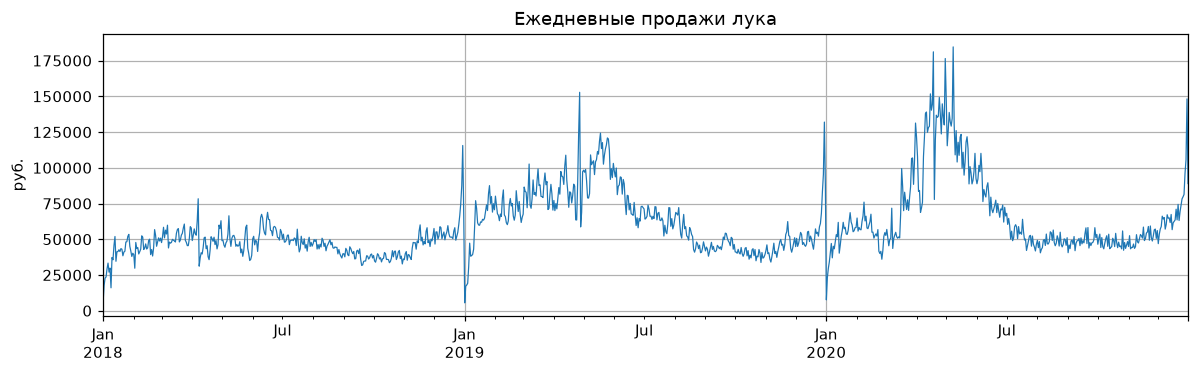

In [2]:
onion = pd.read_csv("../data/onion_sales.csv", parse_dates=["day"], index_col="day")["rto"]
onion.index.freq = "D"  # частота нужна SARIMAX, чтобы уметь продолжать индекс

print(f"{len(onion)} наблюдений: {onion.index[0]:%Y-%m-%d} — {onion.index[-1]:%Y-%m-%d}")

fig, ax = plt.subplots(figsize=(11, 3.5))
onion.plot(ax=ax, lw=0.8, color="C0")
ax.set(title="Ежедневные продажи лука", ylabel="руб.", xlabel="")
fig.tight_layout()

Ряд дневной, значит, в нём как минимум **недельная** сезонность (выходные) и,
скорее всего, **годовая** (сезон овощей, праздники). Простейший регрессор —
признак «рабочий день»:

In [3]:
X_demo = pd.DataFrame({"workday": (onion.index.dayofweek < 5).astype(float)}, index=onion.index)

demo = SARIMAX(onion, exog=X_demo, order=(1, 0, 0), trend="c").fit(disp=False)
print(f"β(workday) = {demo.params['workday']:.1f} руб.  — обучение прошло без проблем")

β(workday) = 59384.8 руб.  — обучение прошло без проблем


In [4]:
try:
    demo.forecast(30)
except Exception as err:
    print(f"{type(err).__name__}: {err}")

ValueError: Out-of-sample operations in a model with a regression component require additional exogenous values via the `exog` argument.


Вот она, ровно та ошибка, ради которой написан этот ноутбук.

🔍 Обратите внимание, насколько она **безобидная**: модель не сломалась, она
просто попросила данные. И в данном случае дать их — тривиально, календарь на
30 дней вперёд известен. Опасность начинается тогда, когда мы точно так же
«просто даём данные» для регрессора, которого на самом деле не знаем.

---
# 1. Способ 1: детерминированные признаки

Детерминированный признак — это тот, который **вычисляется из момента
времени** и больше ни из чего. День недели, номер месяца, квартал, признак
«конец месяца», гармоники Фурье. Их будущее известно абсолютно точно, потому
что календарь на 2027 год уже существует.

## 1.1. Правильный паттерн

Есть один способ работать с такими признаками, при котором ошибиться
невозможно:

> **1. Удлинить индекс на горизонт прогноза.
> 2. Посчитать признаки на всём удлинённом индексе — одной формулой.
> 3. Разрезать результат на исторические и будущие.**

Почему именно так, а не «посчитать на истории, потом досчитать на будущем»?
Потому что во втором случае вы пишете формулу **дважды** и рискуете написать
её по-разному. Классический пример — гармоники Фурье: если в истории считать
$\sin(2\pi k t / m)$ от $t = 0, 1, 2, \dots$, а в будущем заново от $t = 0$, то
сезонная волна на стыке сделает скачок, и модель выдаст ерунду. При счёте на
сплошном индексе это физически невозможно.

Оформим три вспомогательные функции — они понадобятся до конца ноутбука.

In [5]:
def extend_index(idx, h):
    """Удлиняет DatetimeIndex на h шагов вперёд с тем же шагом."""
    freq = idx.freq or pd.infer_freq(idx)
    future = pd.date_range(idx[-1], periods=h + 1, freq=freq, inclusive="right")
    return idx.append(future)


def calendar_features(idx):
    """Календарные признаки — по одному столбцу дамми на день недели (без понедельника)."""
    dow = pd.get_dummies(idx.dayofweek, prefix="dow").astype(float)
    dow.index = idx
    return dow.drop(columns=dow.columns[0])  # базовая категория — понедельник


def fourier(idx, period, order, prefix="f"):
    """order пар гармоник sin/cos с заданным периодом (в шагах индекса)."""
    t = np.arange(len(idx))  # сплошная нумерация по всему индексу — в этом весь смысл
    cols = {}
    for k in range(1, order + 1):
        cols[f"{prefix}_sin{k}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"{prefix}_cos{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=idx)

🔍 Про `calendar_features`. В исходном ноутбуке `5.10` календарные признаки
сделаны иначе — как **целые числа**: `month` от 1 до 12, `dayofweek` от 0 до 6.
Это ошибка, хотя код и работает. Регрессия трактует такой столбец линейно:
«декабрь в 12 раз больше января», «воскресенье в 6 раз больше вторника». А это
бессмыслица — номер месяца категориален, а не количественен.

Правильных вариантов два: **дамми** (как выше) или **гармоники Фурье**
(раздел 2). Дамми точнее описывают короткий цикл, Фурье — экономнее для
длинного.

## 1.2. Применяем паттерн

In [6]:
H = 30  # горизонт прогноза — 30 дней

idx_ext = extend_index(onion.index, H)  # шаг 1: удлинили индекс
print(f"история: {len(onion)} точек, удлинённый индекс: {len(idx_ext)} точек")
print(f"последние 3 даты: {idx_ext[-3:].strftime('%Y-%m-%d').tolist()}")

история: 1096 точек, удлинённый индекс: 1126 точек
последние 3 даты: ['2021-01-28', '2021-01-29', '2021-01-30']


In [7]:
# шаг 2: считаем ВСЕ признаки на удлинённом индексе одним вызовом
X_all = pd.concat(
    [
        calendar_features(idx_ext),
        fourier(idx_ext, period=365.25, order=3, prefix="year"),  # годовая волна
        fourier(idx_ext, period=91.31, order=1, prefix="qrtr"),  # квартальная
    ],
    axis=1,
)

# шаг 3: разрезаем
X_hist, X_future = X_all.iloc[:-H], X_all.iloc[-H:]

print(f"признаков: {X_all.shape[1]}   история: {X_hist.shape}   будущее: {X_future.shape}")
X_all.iloc[:3, :6].round(3)

признаков: 14   история: (1096, 14)   будущее: (30, 14)


,dow_1,dow_2,dow_3,dow_4,dow_5,dow_6
2018-01-01,0.0,0.0,0.0,0.0,0.0,0.0
2018-01-02,1.0,0.0,0.0,0.0,0.0,0.0
2018-01-03,0.0,1.0,0.0,0.0,0.0,0.0


Проверим, что склейка получилась гладкой, — нарисуем годовую гармонику
на стыке истории и будущего.

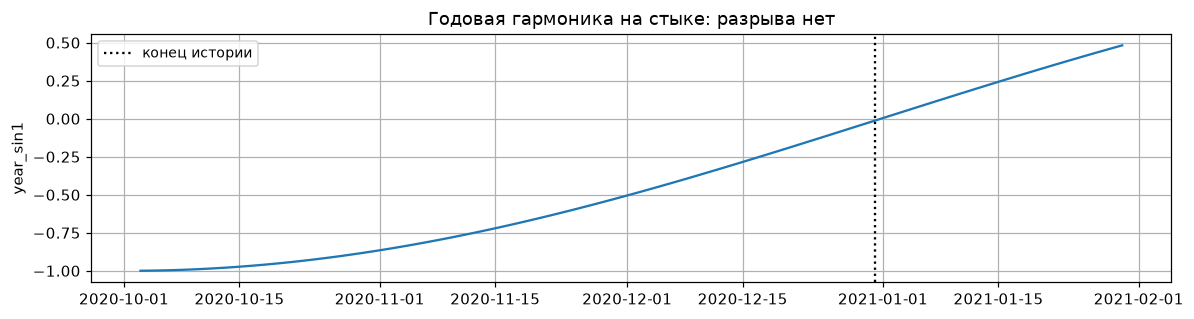

In [8]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(X_all.index[-120:], X_all["year_sin1"].iloc[-120:], color="C0", lw=1.5)
ax.axvline(onion.index[-1], color="black", ls=":", label="конец истории")
ax.set(title="Годовая гармоника на стыке: разрыва нет", ylabel="year_sin1")
ax.legend(fontsize=9)
fig.tight_layout()

## 1.3. Обучаем и прогнозируем

Откладываем последние 30 дней истории как тест — чтобы было чем измерить
качество, — и отдельно строим честный прогноз на 30 дней **за пределы данных**.

In [9]:
y_tr, y_te = onion.iloc[:-H], onion.iloc[-H:]
X_tr, X_te = X_hist.iloc[:-H], X_hist.iloc[-H:]

t0 = time.perf_counter()
m_det = SARIMAX(y_tr, exog=X_tr, order=(0, 1, 2), seasonal_order=(2, 0, 0, 7)).fit(disp=False)
print(f"обучение: {time.perf_counter() - t0:.1f} с,  AIC = {m_det.aic:.1f}")

fc_te = m_det.forecast(H, exog=X_te)
rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
print(f"RMSE на отложенных 30 днях: {rmse(y_te, fc_te):,.0f} руб.")

обучение: 0.6 с,  AIC = 22262.9
RMSE на отложенных 30 днях: 21,507 руб.


А теперь — прогноз в настоящее будущее, за границу данных. Единственное
отличие: в `exog` идёт `X_future`, тот самый кусок, который мы отрезали на
шаге 3.

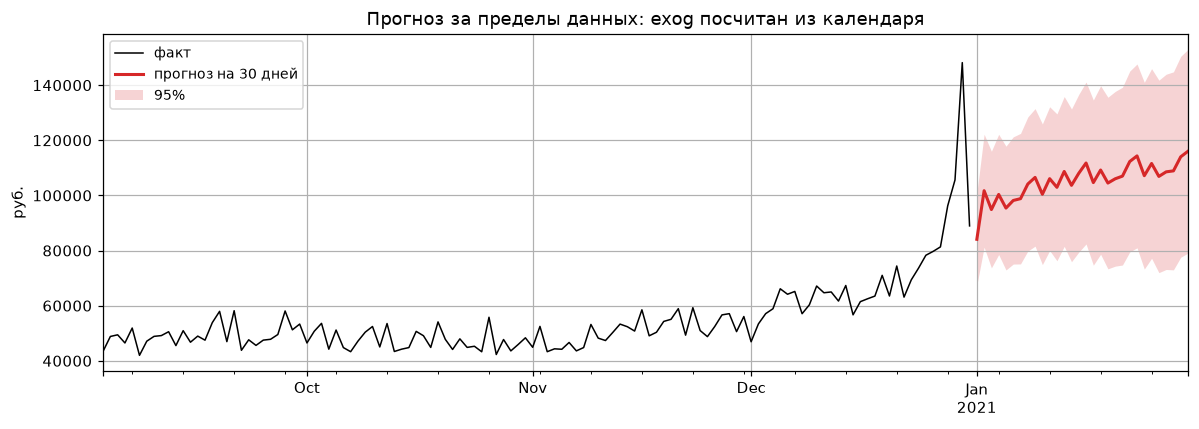

In [10]:
m_full = SARIMAX(onion, exog=X_hist, order=(0, 1, 2), seasonal_order=(2, 0, 0, 7)).fit(disp=False)
fc_future = m_full.get_forecast(H, exog=X_future)

fig, ax = plt.subplots(figsize=(11, 4))
onion.iloc[-120:].plot(ax=ax, color="black", lw=1, label="факт")
fc_future.predicted_mean.plot(ax=ax, color="C3", lw=2, label="прогноз на 30 дней")
ci = fc_future.conf_int()
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="C3", alpha=0.2, lw=0, label="95%")
ax.set(title="Прогноз за пределы данных: exog посчитан из календаря", ylabel="руб.", xlabel="")
ax.legend(fontsize=9)
fig.tight_layout()

## 1.4. То же самое, но встроенным инструментом

Паттерн «удлинить → посчитать → разрезать» настолько типовой, что в
`statsmodels` для него есть готовый класс `DeterministicProcess`. Он хранит
исходный индекс и умеет сам достраивать признаки на любое число шагов вперёд —
и `in_sample()`, и `out_of_sample()` считаются от одной и той же нумерации,
так что рассинхронизация исключена по построению.

In [11]:
dp = DeterministicProcess(
    onion.index,
    constant=False,
    seasonal=True,  # сезонные дамми; для дневного ряда с period=7 это дни недели
    period=7,
    additional_terms=[Fourier(period=365.25, order=3)],
)

Xd_hist = dp.in_sample()
Xd_future = dp.out_of_sample(steps=H)

print(f"in_sample:      {Xd_hist.shape}")
print(f"out_of_sample:  {Xd_future.shape}")
print(f"столбцы совпадают: {list(Xd_hist.columns) == list(Xd_future.columns)}")
Xd_future.iloc[:3, :5].round(3)

in_sample:      (1096, 13)
out_of_sample:  (30, 13)
столбцы совпадают: True


,"s(1,7)","s(2,7)","s(3,7)","s(4,7)","s(5,7)"
2021-01-01,0.0,0.0,0.0,0.0,1.0
2021-01-02,0.0,0.0,0.0,0.0,0.0
2021-01-03,0.0,0.0,0.0,0.0,0.0


🔍 `DeterministicProcess` — то, чем стоит пользоваться в рабочем коде. Ручные
функции выше мы написали не вместо него, а чтобы было видно, **что именно** он
делает: никакой магии, только сплошная нумерация и синус с косинусом.

**Итог по способу 1.** Если признак вычисляется из даты — вопрос «где взять
его на будущее» не стоит вообще. Единственное, что нужно, — не считать его
дважды.

---
# 2. Способ 1а: гармоники Фурье вместо сезонной части

Это, пожалуй, самый практически полезный приём всего семинара.

## 2.1. Зачем

В ноутбуке `01` мы выяснили, что сезонный период $m$ входит в **размерность
вектора состояния** фильтра Калмана, а одна итерация стоит $O(n\cdot r^2)$.
Поэтому SARIMA с $m = 7$ считается мгновенно, с $m = 24$ — заметно, а с
$m = 365$ — очень долго. И это при том, что число оцениваемых параметров не
меняется: у $(1,1,1)(1,1,1)_{365}$ их всё те же четыре.

Альтернатива: **выкинуть сезонную часть модели совсем** и описать сезонность
набором синусов и косинусов, передав их как `exog`. Модель становится

$$y_t = \sum_{k=1}^{K}\Big[a_k \sin\tfrac{2\pi k t}{m} + b_k \cos\tfrac{2\pi k t}{m}\Big] + n_t,
\qquad n_t \sim \text{ARIMA}(p,d,q)$$

и называется **динамической гармонической регрессией** (dynamic harmonic
regression, DHR). Три следствия:

* **Быстро.** Состояние остаётся коротким, гармоники — обычные регрессоры.
* **Экономно по параметрам.** $K$ гармоник — это $2K$ коэффициентов, и обычно
  хватает $K = 2\text{–}6$ вместо $m$ дамми.
* **Работает несколько сезонностей сразу.** Можно сложить гармоники с
  периодами 7, 365.25 и 91.31 — то, чего SARIMA не умеет в принципе: у неё
  ровно одно `seasonal_order`.

Цена: сезонный профиль **фиксирован во времени**. SARIMA-часть позволяет
сезонной волне медленно меняться от года к году, гармоники — нет.

## 2.2. Сколько брать гармоник

$K$ — это гиперпараметр, и подбирается он так же, как порядки: по
информационному критерию. Берём **AICc**, потому что моделей с разным числом
параметров мы сравниваем много, а ряд не бесконечный.

Важно: модели с разным $K$ отличаются только составом `exog`, а $d$ у всех
одинаковый — значит, их правдоподобия сравнимы и AICc осмыслен.

In [12]:
# ⏱ ~5 с: 6 моделей на 1096 наблюдениях
rows = []
for K in range(1, 7):
    Xk = fourier(onion.index, period=7, order=K, prefix="wk")
    r = SARIMAX(onion, exog=Xk, order=(0, 1, 2), trend="n").fit(disp=False)
    rows.append({"K": K, "число гармоник (столбцов)": 2 * K, "AICc": r.aicc, "AIC": r.aic})

tab_K = pd.DataFrame(rows).set_index("K")
tab_K.round(1)

,число гармоник (столбцов),AICc,AIC
K,,,
1,2,23093.2,23093.1
2,4,23067.5,23067.4
3,6,22945.7,22945.6
4,8,22950.1,22949.9
5,10,22954.2,22953.8
6,12,22958.1,22957.7


Минимум AICc — ровно на $K = 3$, дальше критерий растёт. И это не случайность,
а арифметика: у периода 7 больше трёх пар гармоник **не существует**. При целом
$t$

$$\sin\frac{2\pi \cdot 4 t}{7} = \sin\left(2\pi t - \frac{2\pi \cdot 3 t}{7}\right)
= -\sin\frac{2\pi \cdot 3 t}{7}$$

то есть четвёртая гармоника — это третья с обратным знаком, никакой новой
информации в ней нет. Модель послушно оценивает для неё коэффициент и получает
штраф за лишний параметр — что мы и видим в строках $K = 4, 5, 6$.

**Правило.** Для периода $m$ имеет смысл $K \le m/2$. Для $m = 7$ это
$K \le 3$, для $m = 365$ — формально до 182, практически 3–10.

## 2.3. Множественная сезонность: то, чего SARIMA не умеет

Соберём модель, в которой **три** сезонности сразу: недельная, квартальная и
годовая — и всё это без единого `seasonal_order`.

In [13]:
X_multi = pd.concat(
    [
        fourier(idx_ext, period=7, order=3, prefix="wk"),
        fourier(idx_ext, period=91.31, order=1, prefix="qr"),
        fourier(idx_ext, period=365.25, order=3, prefix="yr"),
    ],
    axis=1,
)
Xm_hist, Xm_future = X_multi.iloc[:-H], X_multi.iloc[-H:]

t0 = time.perf_counter()
m_dhr = SARIMAX(onion, exog=Xm_hist, order=(1, 1, 2), trend="n").fit(disp=False)
t_dhr = time.perf_counter() - t0

print(f"DHR: 3 сезонности, {X_multi.shape[1]} столбцов sin/cos (7 пар гармоник)")
print(f"обучение: {t_dhr:.2f} с,  AIC = {m_dhr.aic:.1f}")

DHR: 3 сезонности, 14 столбцов sin/cos (7 пар гармоник)
обучение: 0.14 с,  AIC = 22941.4


## 2.4. Сколько стоит та же годовая сезонность «честной» SARIMA

⏱ **~30 с.** Сравним: попросим SARIMA описать годовую сезонность своими
средствами, то есть с $m = 365$. Чтобы дождаться результата в аудитории,
ограничим ряд двумя годами и число итераций оптимизатора.

In [14]:
onion_2y = onion.loc["2018":"2019"]

t0 = time.perf_counter()
m_365 = SARIMAX(onion_2y, order=(0, 1, 1), seasonal_order=(1, 0, 0, 365)).fit(disp=False, maxiter=15)
t_365 = time.perf_counter() - t0

# та же DHR на том же куске — для честного сравнения
X_2y = pd.concat(
    [
        fourier(onion_2y.index, period=7, order=3, prefix="wk"),
        fourier(onion_2y.index, period=365.25, order=3, prefix="yr"),
    ],
    axis=1,
)
t0 = time.perf_counter()
m_dhr_2y = SARIMAX(onion_2y, exog=X_2y, order=(0, 1, 1), trend="n").fit(disp=False)
t_dhr_2y = time.perf_counter() - t0

pd.DataFrame(
    {
        "время fit, с": [t_365, t_dhr_2y],
        "размерность состояния": [366, 2],
        "оцениваемых параметров": [len(m_365.params), len(m_dhr_2y.params)],
        "AIC": [m_365.aic, m_dhr_2y.aic],
    },
    index=["SARIMA (1,0,0)_365", "DHR: ARIMA(0,1,1) + 12 гармоник"],
).round(2)

,"время fit, с",размерность состояния,оцениваемых параметров,AIC
"SARIMA (1,0,0)_365",34.72,366,3,15237.06
"DHR: ARIMA(0,1,1) + 12 гармоник",0.07,2,14,15097.67


🔍 Разница во времени — **примерно в 500 раз**, и это при том, что SARIMA мы
ещё и ограничили пятнадцатью итерациями оптимизатора (без ограничения она
считалась бы кратно дольше). Причина ровно та, что разобрана в ноутбуке `01`:
у первой модели вектор состояния длиной 366, у второй — длиной 2, а стоимость
итерации фильтра Калмана — $O(n\cdot r^2)$.

Смотрим на два оставшихся столбца — там сюрприз. У DHR **параметров больше**
(14 против 3: двенадцать коэффициентов при гармониках плюс MA и $\sigma^2$), и
всё равно AIC у неё **лучше**. То есть быстрая модель здесь ещё и точнее
описывает данные.

Сравнивать AIC в этой таблице законно: у обеих моделей $d = 1$ и $D = 0$,
значит, правдоподобия считаются для одного и того же
продифференцированного ряда (в ноутбуке `02` мы разбирали, почему при разных
$d$ такое сравнение было бы бессмысленным).

**Практический вывод.** Правило, которое стоит запомнить целиком:

> Если $m$ больше примерно 24 — не используйте `seasonal_order`. Опишите
> сезонность гармониками Фурье в `exog`, а `seasonal_order` оставьте пустым
> или отдайте короткому циклу (неделе).

Именно так устроен ноутбук `5.10`, на котором основан этот раздел:
`seasonal_order=(2,0,0,7)` для недели плюс гармоники на 365.25 и 91.31 —
гибрид, где каждая часть занимается тем, что ей дёшево.

---
# 3. Способ 2: регрессоры, известные по плану или контракту

Второй по надёжности класс — то, что не вычисляется из даты, но **известно
заранее из внешнего источника**: календарь праздников, график промо-акций,
план производства, объявленные тарифы, расходы на рекламу по подписанному
контракту. Формально это данные, а не функция времени, но на горизонте
прогноза они уже определены.

## 3.1. Данные: спрос на электроэнергию

Переходим к сквозному ряду семинара — суточному потреблению электроэнергии в
штате Виктория (Австралия) за 2014 год. Здесь есть и температура, и календарь
праздников.

In [15]:
raw = pd.read_csv("../data/vic_elec.csv", parse_dates=["Time"])
raw["Date"] = pd.to_datetime(raw["Date"])

# получасовые данные → суточные
daily = raw.groupby("Date").agg(
    Demand=("Demand", "sum"),
    Temperature=("Temperature", "max"),  # дневной максимум — он и включает кондиционеры
    Holiday=("Holiday", "first"),
)
daily.index.freq = "D"
daily["Demand"] /= 1000  # ГВт·ч

vic = daily.loc["2014"]
print(f"{len(vic)} дней, праздников: {int(vic['Holiday'].sum())}")
print("даты праздников:", vic.index[vic["Holiday"].astype(bool)].strftime("%d.%m").tolist())

365 дней, праздников: 10
даты праздников: ['01.01', '27.01', '10.03', '18.04', '21.04', '25.04', '09.06', '04.11', '25.12', '26.12']


## 3.2. Собираем регрессоры

Три содержательных признака:

* `temp` и `temp2` — температура и её квадрат. Квадрат нужен, потому что связь
  **нелинейная и U-образная**: и жара (кондиционеры), и холод (обогрев)
  повышают спрос, а комфортные 18–20° дают минимум.
* `workday` — рабочий день. Учитывает и выходные, и праздники: 25 декабря
  заводы стоят так же, как в воскресенье.

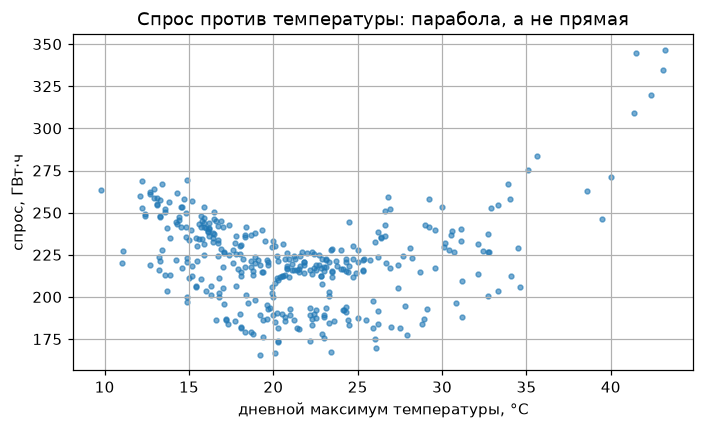

In [16]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.scatter(vic["Temperature"], vic["Demand"], s=10, c="C0", alpha=0.6)
ax.set(xlabel="дневной максимум температуры, °C", ylabel="спрос, ГВт·ч",
       title="Спрос против температуры: парабола, а не прямая")
fig.tight_layout()

In [17]:
def vic_exog(index, temperature, holiday):
    """Регрессоры для модели спроса. index/temperature/holiday — одной длины."""
    weekend = pd.Index(index).dayofweek.isin([5, 6])
    return pd.DataFrame(
        {
            "temp": np.asarray(temperature, dtype=float),
            "temp2": np.asarray(temperature, dtype=float) ** 2,
            "workday": (~(np.asarray(holiday, dtype=bool) | weekend)).astype(float),
        },
        index=index,
    )


X_vic = vic_exog(vic.index, vic["Temperature"], vic["Holiday"])

Hv = 14  # прогнозируем последние две недели года
yv_tr, yv_te = vic["Demand"].iloc[:-Hv], vic["Demand"].iloc[-Hv:]
Xv_tr, Xv_te = X_vic.iloc[:-Hv], X_vic.iloc[-Hv:]

m_vic = SARIMAX(yv_tr, exog=Xv_tr, order=(1, 0, 1), seasonal_order=(0, 1, 1, 7)).fit(disp=False)
m_vic.params.round(4)

temp       -7.7334
temp2       0.1814
workday    35.2286
ar.L1       0.8548
ma.L1      -0.0205
ma.S.L7    -0.8550
sigma2     41.2204
dtype: float64

Читаем коэффициенты (напомним из ноутбука `04`: в SARIMAX $\beta$
интерпретируется как в обычной регрессии, на уровнях):

* `temp` отрицательный, `temp2` положительный — это и есть парабола ветвями
  вверх. Минимум достигается при $-\beta_{temp} / (2\beta_{temp^2})$;
* `workday` — насколько рабочий день «дороже» нерабочего в ГВт·ч.

In [18]:
t_min = -m_vic.params["temp"] / (2 * m_vic.params["temp2"])
print(f"минимум спроса при температуре   : {t_min:.1f} °C")
print(f"надбавка за рабочий день          : {m_vic.params['workday']:+.1f} ГВт·ч")

минимум спроса при температуре   : 21.3 °C
надбавка за рабочий день          : +35.2 ГВт·ч


## 3.3. Вклад регрессора: измеряем сценарием

Тестовый период — 18–31 декабря 2014, и в нём два праздника: 25 и 26 декабря.
Календарь праздников на год вперёд известен точно, так что это чистый способ 2.

А заодно — приём, которым **измеряют важность регрессора без всякой
статистики**: строим два прогноза, отличающиеся только этим регрессором, и
смотрим на расхождение.

In [19]:
X_real = Xv_te.copy()  # как есть: 25 и 26 декабря — нерабочие
X_nohol = vic_exog(  # «а если бы про праздники забыли»
    vic.index[-Hv:], vic["Temperature"].iloc[-Hv:], np.zeros(Hv, dtype=bool)
)

fc_real = m_vic.get_forecast(Hv, exog=X_real).summary_frame(alpha=0.05)
fc_nohol = m_vic.get_forecast(Hv, exog=X_nohol).summary_frame(alpha=0.05)

cmp = pd.DataFrame(
    {
        "факт": yv_te.to_numpy(),
        "с праздниками": fc_real["mean"].to_numpy(),
        "без праздников": fc_nohol["mean"].to_numpy(),
        "расхождение": fc_nohol["mean"].to_numpy() - fc_real["mean"].to_numpy(),
    },
    index=yv_te.index.strftime("%d.%m (%a)"),
)
cmp.round(1)

,факт,с праздниками,без праздников,расхождение
Date,,,,
18.12 (Thu),216.4,218.0,218.0,0.0
19.12 (Fri),206.1,211.9,211.9,0.0
20.12 (Sat),189.2,186.3,186.3,0.0
21.12 (Sun),203.7,206.6,206.6,0.0
22.12 (Mon),230.3,218.8,218.8,0.0
23.12 (Tue),220.0,221.5,221.5,0.0
24.12 (Wed),193.2,217.1,217.1,0.0
25.12 (Thu),167.0,185.2,220.4,35.2
26.12 (Fri),166.7,179.0,214.2,35.2


RMSE с праздниками : 18.7 ГВт·ч
RMSE без праздников: 26.0 ГВт·ч


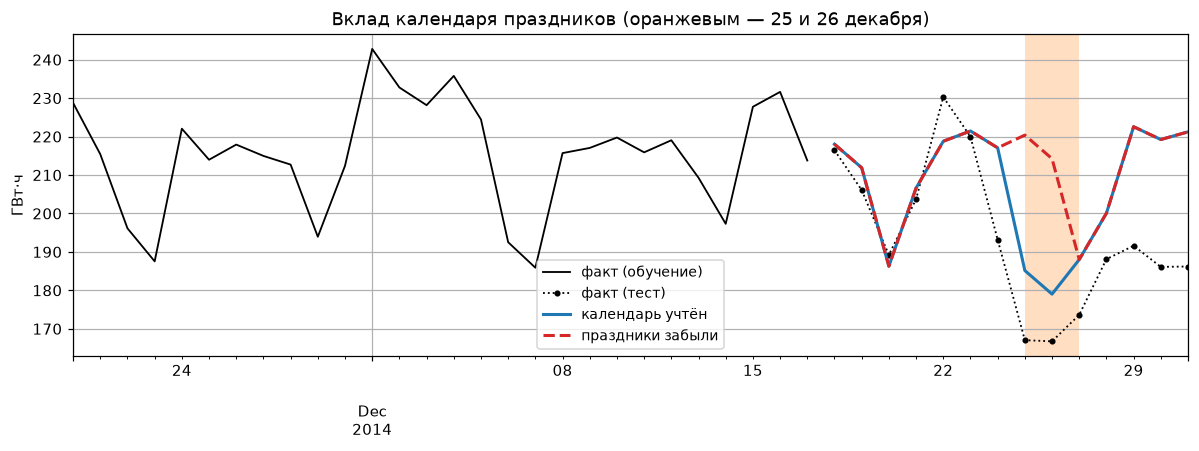

In [20]:
fig, ax = plt.subplots(figsize=(11, 4.2))
yv_tr.iloc[-28:].plot(ax=ax, color="black", lw=1.2, label="факт (обучение)")
yv_te.plot(ax=ax, color="black", lw=1.2, ls=":", marker="o", ms=3, label="факт (тест)")
ax.plot(fc_real.index, fc_real["mean"], color="C0", lw=2, label="календарь учтён")
ax.plot(fc_nohol.index, fc_nohol["mean"], color="C3", lw=2, ls="--", label="праздники забыли")
for d in vic.index[-Hv:][vic["Holiday"].iloc[-Hv:].astype(bool)]:
    ax.axvspan(d, d + pd.Timedelta("1D"), color="C1", alpha=0.25, lw=0)
ax.set(title="Вклад календаря праздников (оранжевым — 25 и 26 декабря)", ylabel="ГВт·ч", xlabel="")
ax.legend(fontsize=9)
fig.tight_layout()

print(f"RMSE с праздниками : {rmse(yv_te, fc_real['mean']):.1f} ГВт·ч")
print(f"RMSE без праздников: {rmse(yv_te, fc_nohol['mean']):.1f} ГВт·ч")

Учёт двух праздничных дней снизил RMSE на всём тестовом отрезке с 26.0 до
18.7 ГВт·ч — почти на треть, и всё это за счёт двух дней из четырнадцати.

🔍 **Приём, который стоит унести.** Разница двух прогнозов, отличающихся ровно
одним регрессором, — это и есть **измеренный вклад этого регрессора в
прогноз**, в единицах прогнозируемой величины. В отличие от p-value, такое
число можно показать заказчику: «учёт праздничного календаря снижает прогноз
спроса на 35 ГВт·ч в конкретные дни».

🔍 И посмотрите на столбец «расхождение» внимательно. Он равен либо нулю, либо
**ровно 35.2** — то есть в точности $\hat\beta_{workday}$ из `summary()`. Это
не совпадение, а прямая проверка формулы из ноутбука `04`:

$$\hat y_{T+h} = \hat\beta' x_{T+h} + \hat n_{T+h}$$

ARIMA-часть $\hat n_{T+h}$ от будущего `exog` не зависит вообще, поэтому при
изменении одного регрессора на $\Delta$ прогноз меняется ровно на
$\hat\beta \cdot \Delta$ — линейно и без всякого «размазывания» по соседним
дням. Именно поэтому такое измерение вклада вообще имеет смысл.

Ровно так же в исходном ноутбуке `5.7` оценивали вклад рекламы: сравнивали
прогноз при фактическом рекламном бюджете с прогнозом при бюджете,
зафиксированном на постоянном уровне.

---
# 4. Способ 3: сценарные регрессоры (what-if)

Температуру на две недели вперёд мы **не знаем**. Можно задать её рукой — и
это законный приём, но результат нужно правильно называть.

> `forecast(exog=<придуманное значение>)` возвращает не прогноз, а **условный
> прогноз**: «спрос будет таким, **если** температура окажется такой».

Разница не философская. Прогноз можно проверить по факту и посчитать по нему
метрику. Условный прогноз проверить нельзя: если температура оказалась другой,
модель ни в чём не виновата.

## 4.1. Одна линия — плохая подача

В ноутбуке `5.7` сделано именно так: всем будущим дням проставлено 26 °C, и
нарисована одна кривая. Читатель графика увидит «прогноз спроса» и не узнает,
что за ним стоит произвольное допущение.

## 4.2. Веер сценариев — хорошая подача

Считаем три прогноза: пессимистичный, базовый и оптимистичный — и показываем
их вместе. Для спроса на электроэнергию «плохо» — это жара.

,средний спрос,ширина PI (h=1)
сценарий,,
"прохладно, 18°",204.24,25.17
"норма, 26°",206.23,25.17
"жара, 35°",236.22,25.17


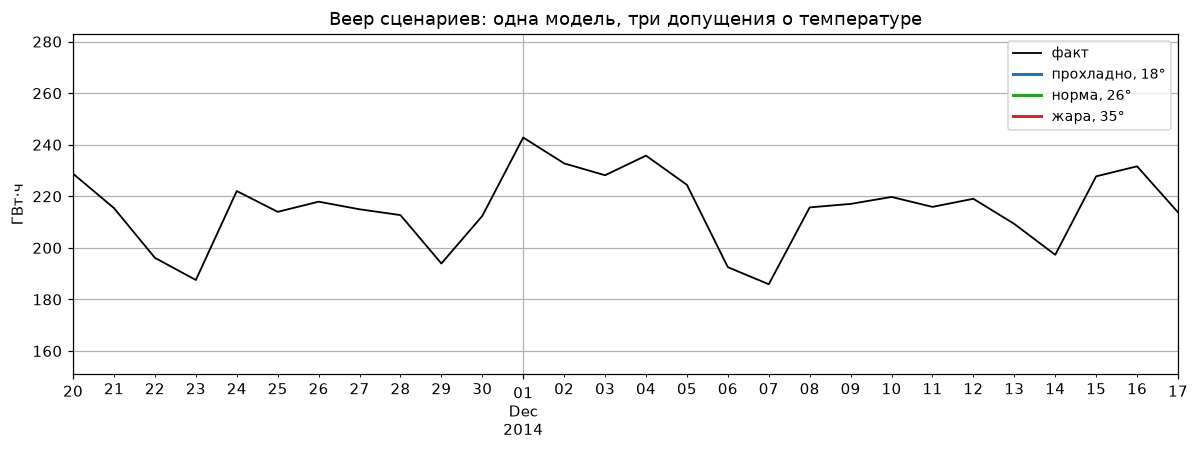

In [21]:
scenarios = {
    "прохладно, 18°": 18.0,
    "норма, 26°": 26.0,
    "жара, 35°": 35.0,
}

fig, ax = plt.subplots(figsize=(11, 4.2))
yv_tr.iloc[-28:].plot(ax=ax, color="black", lw=1.2, label="факт")

rows = []
for (name, t_deg), color in zip(scenarios.items(), ["C0", "C2", "C3"]):
    Xs = vic_exog(vic.index[-Hv:], np.full(Hv, t_deg), vic["Holiday"].iloc[-Hv:])
    fr = m_vic.get_forecast(Hv, exog=Xs).summary_frame(alpha=0.05)
    ax.plot(fr.index, fr["mean"], color=color, lw=2, label=name)
    ax.fill_between(fr.index, fr["mean_ci_lower"], fr["mean_ci_upper"], color=color, alpha=0.12, lw=0)
    rows.append(
        {
            "сценарий": name,
            "средний спрос": fr["mean"].mean(),
            "ширина PI (h=1)": fr["mean_ci_upper"].iloc[0] - fr["mean_ci_lower"].iloc[0],
        }
    )

ax.set(title="Веер сценариев: одна модель, три допущения о температуре", ylabel="ГВт·ч", xlabel="")
ax.legend(fontsize=9)
fig.tight_layout()

pd.DataFrame(rows).set_index("сценарий").round(2)

🔍 Посмотрите на последний столбец таблицы: **ширина интервала во всех трёх
сценариях одинаковая** — 25.17 до второго знака. Это тот самый результат,
который мы доказали в ноутбуке `04`, раздел 5.5: в формуле
$v_{T+h} = \hat\sigma^2\sum_{j<h}\psi_j^2$ нет ни $x$, ни $\beta$, поэтому
неопределённость `exog` в ленту не входит.

Разброс между сценариями — это **другая, не учтённая моделью
неопределённость**. И на этом ряду она больше, чем сама лента: расстояние
между «нормой» и «жарой» — 30 ГВт·ч против 25 ГВт·ч ширины 95 %-го интервала.

🔍 А вот второй столбец таблицы стоит разобрать отдельно, потому что он
выглядит как ошибка: сценарии «прохладно, 18°» и «норма, 26°» дали почти
одинаковый спрос — 204 и 206 ГВт·ч. Это не ошибка, а парабола из раздела 3.2:
минимум спроса приходится на 21.3 °C, а 18° и 26° лежат от него почти на
равном расстоянии по разные стороны. Модель говорит буквально то, что мы в неё
заложили: и охлаждение, и нагрев требуют электричества, а разница в 4–5° от
точки комфорта в любую сторону стоит одинаково.

Полезный вывод для сценарного анализа: **при нелинейном регрессоре
«пессимистичный» сценарий по $x$ не обязан быть пессимистичным по $y$.**
Сценарии надо выбирать по значению $y$, а не по значению $x$.

**Правило подачи.** Сценарный прогноз показывают минимум тремя линиями и
подписывают допущение прямо на графике. Одна линия без подписи — это
дезинформация, даже если код написан правильно.

---
# 5. Способ 4: спрогнозировать регрессор отдельной моделью

Самый соблазнительный способ: раз $x$ — тоже временной ряд, обучим на нём
ARIMA, возьмём прогноз и подставим в основную модель. Технически это работает
в четыре строки. Проблема в том, что происходит с интервалом.

## 5.1. Прогнозируем температуру

Температура сама по себе прогнозируется плохо дальше нескольких дней, но у неё
есть сильная годовая сезонность — а её мы уже умеем описывать гармониками
(способ 1а). Берём всю доступную историю (2012–2014), AR(2) плюс годовые
гармоники.

In [22]:
temp_hist = daily["Temperature"].iloc[:-Hv]  # вся история, кроме тестовых 14 дней
idx_t = extend_index(temp_hist.index, Hv)
F_t = fourier(idx_t, period=365.25, order=2, prefix="yr")

m_temp = SARIMAX(temp_hist, exog=F_t.iloc[:-Hv], order=(2, 0, 0), trend="c").fit(disp=False)
fc_temp = m_temp.get_forecast(Hv, exog=F_t.iloc[-Hv:])

pd.DataFrame(
    {
        "прогноз T": fc_temp.predicted_mean.to_numpy(),
        "se прогноза T": fc_temp.se_mean.to_numpy(),
        "факт T": daily["Temperature"].iloc[-Hv:].to_numpy(),
    },
    index=yv_te.index.strftime("%d.%m"),
).round(1)

,прогноз T,se прогноза T,факт T
Date,,,
18.12,22.6,3.6,24.0
19.12,24.5,4.1,19.9
20.12,25.6,4.1,23.0
21.12,25.9,4.1,33.3
22.12,25.9,4.1,24.7
23.12,25.9,4.1,26.7
24.12,25.9,4.1,22.2
25.12,26.0,4.1,23.4
26.12,26.1,4.1,20.1


Прогноз быстро выходит на сезонную норму (~26 °C — австралийское лето), а
стандартная ошибка стабилизируется около 4 °C. Иными словами, дальше двух-трёх
дней модель говорит: «будет как обычно в это время года, ±4 градуса».

## 5.2. Подставляем и получаем «прогноз»

In [23]:
X_plug = vic_exog(vic.index[-Hv:], fc_temp.predicted_mean, vic["Holiday"].iloc[-Hv:])
fc_plug = m_vic.get_forecast(Hv, exog=X_plug).summary_frame(alpha=0.05)

print(f"RMSE прогноза спроса по прогнозной T: {rmse(yv_te, fc_plug['mean']):.1f} ГВт·ч")
print(f"RMSE того же прогноза по фактической T: {rmse(yv_te, fc_real['mean']):.1f} ГВт·ч")

RMSE прогноза спроса по прогнозной T: 20.6 ГВт·ч
RMSE того же прогноза по фактической T: 18.7 ГВт·ч


## 5.3. Что не так с интервалом

Формально мы получили прогноз с 95 %-м интервалом. Но интервал построен в
предположении, что температура **известна точно** — а мы только что видели, что
её собственная ошибка ±4 °C.

Оценим, во что это обходится. Методика — симуляция:

1. сгенерируем 500 **траекторий** температуры из её прогнозного распределения
   (`simulate` учитывает и шум, и автокорреляцию — а не просто рисует
   независимые точки вокруг среднего);
2. для каждой траектории построим прогноз спроса;
3. к каждому прогнозу добавим собственный шум модели спроса — тот, что и даёт
   аналитический интервал;
4. по 500 полученным траекториям спроса возьмём квантили 2.5 % и 97.5 %.

Результат — интервал, который учитывает **оба** источника неопределённости.

In [24]:
# ⏱ ~5 с
N_SIM = 500

temp_paths = np.asarray(m_temp.simulate(Hv, anchor="end", repetitions=N_SIM, exog=F_t.iloc[-Hv:]))
temp_paths = temp_paths.reshape(Hv, N_SIM)

se_demand = fc_plug["mean_se"].to_numpy()  # se аналитического интервала спроса
draws = np.empty((Hv, N_SIM))

for j in range(N_SIM):
    Xj = vic_exog(vic.index[-Hv:], temp_paths[:, j], vic["Holiday"].iloc[-Hv:])
    mean_j = m_vic.get_forecast(Hv, exog=Xj).predicted_mean.to_numpy()
    draws[:, j] = mean_j + rng.normal(0, se_demand)  # + собственный шум модели спроса

lo_sim, hi_sim = np.quantile(draws, [0.025, 0.975], axis=1)

width = pd.DataFrame(
    {
        "аналитический PI": fc_plug["mean_ci_upper"].to_numpy() - fc_plug["mean_ci_lower"].to_numpy(),
        "PI с учётом ошибки T": hi_sim - lo_sim,
    },
    index=yv_te.index.strftime("%d.%m"),
)
width["во сколько раз шире"] = width.iloc[:, 1] / width.iloc[:, 0]
width.round(2)

,аналитический PI,PI с учётом ошибки T,во сколько раз шире
Date,,,
18.12,25.17,28.06,1.11
19.12,32.78,41.29,1.26
20.12,37.37,46.39,1.24
21.12,40.40,49.49,1.22
22.12,42.47,55.01,1.30
23.12,43.93,56.36,1.28
24.12,44.96,52.87,1.18
25.12,46.50,53.64,1.15
26.12,47.57,54.07,1.14


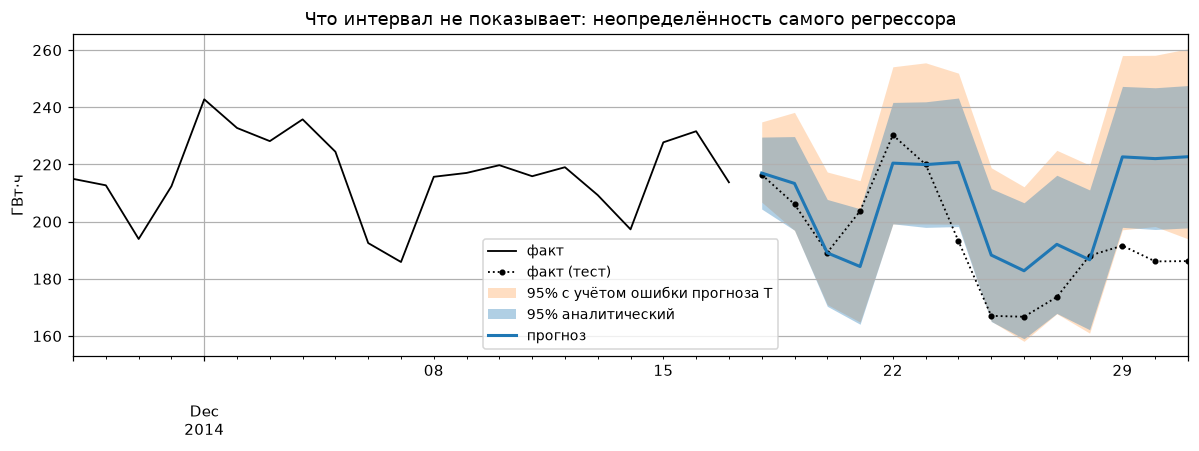

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.2))
yv_tr.iloc[-21:].plot(ax=ax, color="black", lw=1.2, label="факт")
yv_te.plot(ax=ax, color="black", lw=1.2, ls=":", marker="o", ms=3, label="факт (тест)")

ax.fill_between(fc_plug.index, lo_sim, hi_sim, color="C1", alpha=0.25, lw=0,
                label="95% с учётом ошибки прогноза T")
ax.fill_between(fc_plug.index, fc_plug["mean_ci_lower"], fc_plug["mean_ci_upper"],
                color="C0", alpha=0.35, lw=0, label="95% аналитический")
ax.plot(fc_plug.index, fc_plug["mean"], color="C0", lw=2, label="прогноз")

ax.set(title="Что интервал не показывает: неопределённость самого регрессора",
       ylabel="ГВт·ч", xlabel="")
ax.legend(fontsize=9)
fig.tight_layout()

In [26]:
inside_an = ((yv_te.to_numpy() >= fc_plug["mean_ci_lower"].to_numpy())
             & (yv_te.to_numpy() <= fc_plug["mean_ci_upper"].to_numpy())).mean()
inside_sim = ((yv_te.to_numpy() >= lo_sim) & (yv_te.to_numpy() <= hi_sim)).mean()
print(f"факт попал в аналитический PI      : {inside_an:.0%} дней из 14")
print(f"факт попал в PI с учётом ошибки T  : {inside_sim:.0%} дней из 14")

факт попал в аналитический PI      : 71% дней из 14
факт попал в PI с учётом ошибки T  : 71% дней из 14


Честный интервал получился на **20–30 % шире** аналитического. Проценты
кажутся скромными, но на первый шаг разница почти нулевая, а дальше растёт:
при $h = 1$ температуру ещё можно угадать, при $h = 14$ — нет.

🔍 А вот покрытие расширение интервала **не спасло** — 71 % в обоих случаях,
при заявленных 95 %. Два замечания по этому поводу.

Во-первых, 14 точек — это не выборка для измерения покрытия. Одно попадание
или промах меняют результат на 7 процентных пунктов; корректно мерить покрытие
нужно на rolling-origin CV, как в ноутбуке `04`, раздел 6.

Во-вторых — и это важнее — посмотрите, **где** факт вылетел за границы.
Вернитесь к таблице из раздела 3.3: 24, 29, 30 и 31 декабря модель
прогнозирует 217–223 ГВт·ч, а фактически было 186–193. Это промах не по
температуре. Это новогодняя неделя: половина страны в
отпуске, промышленность стоит, а в календаре `Holiday` отмечены только 25 и
26 декабря. Модель про эту неделю просто не знает.

То есть промахи здесь — не от неопределённости регрессора, а от **отсутствия
нужного регрессора**. Никакое расширение интервала такое не лечится; лечится
дамми на новогоднюю неделю — это способ 6, раздел 7.

🔍 **Главное предупреждение способа 4.** Аналитический интервал в такой схеме
систематически **слишком узкий**, и `statsmodels` об этом не предупредит: с его
точки зрения вы передали точно известные данные.

Что с этим делать:

1. **Честно расширять интервал симуляцией** — как выше. Дороже, но правильно.
2. **Заменить прогноз регрессора сценариями** (способ 3): вместо одной ложно
   точной линии — веер, где допущение видно.
3. **Взять лаг вместо текущего значения** (способ 5): если модели хватает
   $x_{t-h}$, прогнозировать регрессор вообще не нужно.
4. Если ошибка прогноза $x$ велика, а $\beta$ мал — возможно, регрессор просто
   не нужен. Проверка — в разделе 8.

И общее правило: **регрессор имеет смысл ровно настолько, насколько его будущее
известно лучше, чем будущее самого $y$.** Прогнозировать спрос по
спрогнозированной температуре — значит заменить одну неизвестную на другую.

---
# 6. Способ 5: лаговые регрессоры

Самый изящный выход. Если модель использует не $x_t$, а $x_{t-k}$, то на
горизонте $h$ ей нужны значения $x_{T+h-k}$. И если

$$\boxed{\,k \ge h\,}$$

то $T + h - k \le T$ — все нужные значения **уже наблюдены**. Прогнозировать
регрессор не нужно вообще, а неопределённость из раздела 5 исчезает.

## 6.1. Данные: индексы настроений и розничная торговля

Переходим к третьему ряду ноутбука. В файле `data.tsv` — месячные данные:

* `RTRD` — оборот розничной торговли, млрд руб. (это $y$);
* `USD` — курс доллара;
* `levada_IPN` — индекс потребительских настроений «Левада-центра»
  (строится по социологическим опросам);
* `poiskInd_corr` — индекс обеспокоенности, построенный по поисковым запросам.

Содержательный вопрос: **помогают ли индексы настроений прогнозировать
розничную торговлю?** Это классический сюжет — люди строят такие индикаторы
именно в надежде «поймать кризис раньше».

138 месяцев: 2008-09 — 2020-02


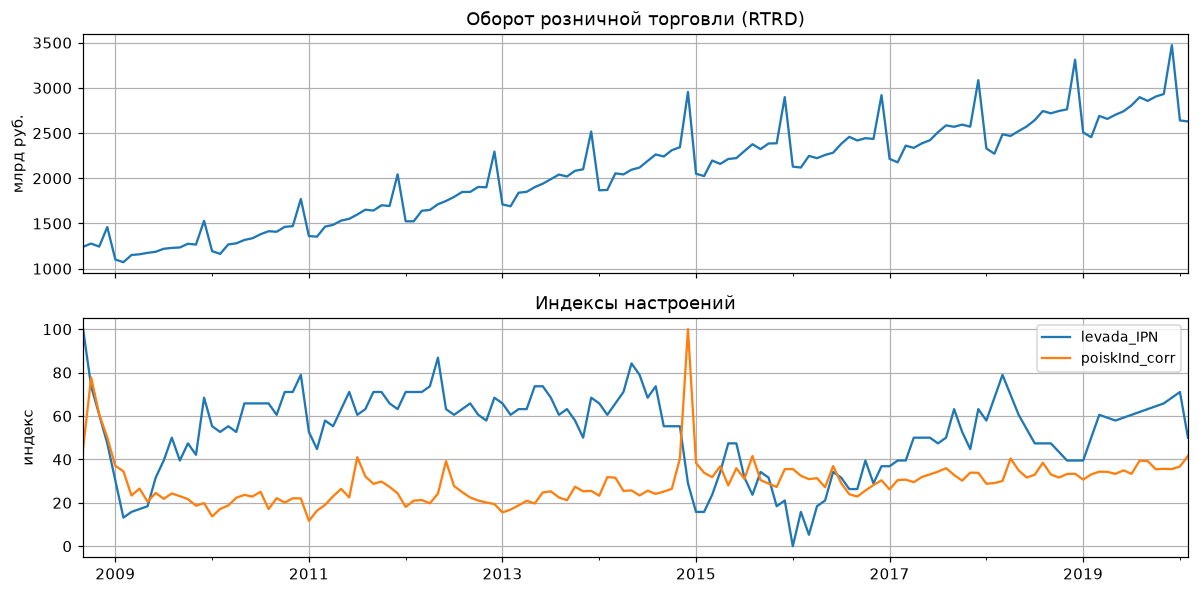

In [27]:
idx_df = pd.read_csv("../data/data.tsv", sep="\t", parse_dates=["fielddate"], index_col="fielddate")
idx_df = idx_df.dropna()  # индекс Левады начинается позже остальных
idx_df.index.freq = "MS"

print(f"{len(idx_df)} месяцев: {idx_df.index[0]:%Y-%m} — {idx_df.index[-1]:%Y-%m}")

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True)
idx_df["RTRD"].plot(ax=axes[0], color="C0")
axes[0].set(ylabel="млрд руб.", title="Оборот розничной торговли (RTRD)")
idx_df[["levada_IPN", "poiskInd_corr"]].plot(ax=axes[1])
axes[1].set(ylabel="индекс", xlabel="", title="Индексы настроений")
axes[1].legend(fontsize=9)
fig.tight_layout()

## 6.2. Инструмент: `make_lags`

In [28]:
def make_lags(x, lags, prefix=None):
    """DataFrame из лагов ряда x. lags=[0,1,2] → x_t, x_{t-1}, x_{t-2}."""
    prefix = prefix or (x.name or "x")
    return pd.DataFrame({f"{prefix}_lag{k}": x.shift(k) for k in lags})


make_lags(idx_df["levada_IPN"], [0, 1, 2]).head(4)

,levada_IPN_lag0,levada_IPN_lag1,levada_IPN_lag2
fielddate,,,
2008-09-01,100.000000,NaN,NaN
2008-10-01,73.684211,100.000000,NaN
2008-11-01,60.526316,73.684211,100.000000
2008-12-01,47.368421,60.526316,73.684211


🔍 Первые строки — `NaN`, и это неизбежно: у первого месяца нет предыдущего.
Их придётся отрезать, причём **одновременно у `X` и у `y`**, иначе ряды
разъедутся на одно наблюдение. Это одна из самых частых ошибок в коде с
лагами: в исходном ноутбуке `5.6` выравнивание сделано вручную (`shift(1)`
отдельно, срез `[1:]` отдельно) — работает, но проверять приходится глазами.

Надёжнее собрать всё в один DataFrame и сделать `dropna()` один раз:

In [29]:
def align(y, X):
    """Склеивает y и X, выбрасывает строки с NaN, возвращает выровненную пару."""
    both = pd.concat([y.rename("__y__"), X], axis=1).dropna()
    return both["__y__"].rename(y.name), both.drop(columns="__y__")

## 6.3. Сколько лагов брать: выбор по AICc

Та же логика, что с числом гармоник: перебираем наборы лагов, сравниваем AICc.
Здесь важна оговорка — **набор лагов должен быть согласован с горизонтом**.
Прогнозируем на 1 месяц вперёд, значит, допустимы лаги от 1 и больше; лаг 0
в модель включать нельзя, хотя технически он и улучшит подгонку.

Порядок SARIMA возьмём фиксированным, чтобы сравнивались именно наборы
регрессоров: $(1,1,1)(0,1,1)_{12}$ — типичная спецификация для месячного ряда с
трендом и годовой сезонностью.

In [30]:
ORDER, SORDER = (1, 1, 1), (0, 1, 1, 12)

lag_sets = {
    "без регрессоров": [],
    "лаг 1": [1],
    "лаги 1–2": [1, 2],
    "лаги 1–3": [1, 2, 3],
    "лаги 1–6": [1, 2, 3, 4, 5, 6],
}

rows = []
for name, lags in lag_sets.items():
    if lags:
        Xl = make_lags(idx_df["levada_IPN"], lags, prefix="lev")
        yl, Xl = align(idx_df["RTRD"], Xl)
        r = SARIMAX(yl, exog=Xl, order=ORDER, seasonal_order=SORDER).fit(disp=False)
    else:
        # чтобы AICc был сравним, обучаем на том же отрезке, что и самая длинная модель
        r = SARIMAX(idx_df["RTRD"], order=ORDER, seasonal_order=SORDER).fit(disp=False)
    rows.append({"набор": name, "k": len(r.params), "AIC": r.aic, "AICc": r.aicc, "BIC": r.bic})

pd.DataFrame(rows).set_index("набор").round(1)

,k,AIC,AICc,BIC
набор,,,,
без регрессоров,4,1273.6,1273.9,1284.9
лаг 1,5,1252.1,1252.6,1266.2
лаги 1–2,6,1245.0,1245.7,1261.9
лаги 1–3,7,1236.9,1237.9,1256.5
лаги 1–6,10,1210.7,1212.7,1238.5


🔍 **Внимание на оговорку в коде.** Модели в этой таблице обучены на слегка
разных отрезках: у модели с лагами 1–6 первые шесть месяцев съел `dropna()`.
Строго говоря, их правдоподобия сравнивать нельзя — ровно по той же причине,
по которой в ноутбуке `02` нельзя было сравнивать по AIC модели с разным $d$:
**это правдоподобия разных выборок**.

Как делать правильно: обрезать все модели по самому длинному лагу заранее,
чтобы выборка у всех была одна и та же. Ниже — исправленная версия.

In [31]:
MAXLAG = 6
common = idx_df.index[MAXLAG:]  # общий отрезок для всех моделей

rows = []
for name, lags in lag_sets.items():
    y_c = idx_df.loc[common, "RTRD"]
    if lags:
        Xl = make_lags(idx_df["levada_IPN"], lags, prefix="lev").loc[common]
        r = SARIMAX(y_c, exog=Xl, order=ORDER, seasonal_order=SORDER).fit(disp=False)
    else:
        r = SARIMAX(y_c, order=ORDER, seasonal_order=SORDER).fit(disp=False)
    rows.append({"набор": name, "n": int(r.nobs), "k": len(r.params), "AICc": r.aicc})

tab_lags = pd.DataFrame(rows).set_index("набор")
tab_lags.round(1)

,n,k,AICc
набор,,,
без регрессоров,132,4,1212.6
лаг 1,132,5,1206.3
лаги 1–2,132,6,1208.4
лаги 1–3,132,7,1210.3
лаги 1–6,132,10,1212.7


🔍 **Сравните две таблицы — вывод изменился на противоположный.**

| Набор | AICc «как получилось» | AICc на общей выборке |
|---|---|---|
| без регрессоров | 1273.9 | 1212.6 |
| лаг 1 | 1252.6 | **1206.3** ← минимум |
| лаги 1–2 | 1245.7 | 1208.4 |
| лаги 1–3 | 1237.9 | 1210.3 |
| лаги 1–6 | **1212.7** ← минимум | 1212.7 |

В первой таблице AICc монотонно падает, и «победителем» выглядит самый
большой набор — шесть лагов. Во второй, где у всех моделей одна и та же
выборка, минимум приходится на **один** лаг, а шесть лагов оказываются худшим
вариантом из всех, даже хуже модели без регрессоров.

Разгадка в столбце `n` первой таблицы, которого там нет. Каждый лишний лаг
отрезал ещё один месяц из начала выборки — а это самое начало 2008–2009 года,
то есть кризис. Модели с длинными лагами обучались на более коротком и **более
спокойном** ряде, получали более высокое правдоподобие и выглядели лучше. Мы
сравнивали не спецификации, а выборки.

**Правило.** Прежде чем сравнивать модели по любому информационному критерию,
убедитесь, что `nobs` у них совпадает. Это та же ошибка, что сравнение моделей
с разным $d$ из ноутбука `02`, только замаскированная под безобидный
`dropna()`.

После исправления правило выбора обычное: берём минимальный AICc, но только
если выигрыш заметен. Здесь «лаг 1» лучше «без регрессоров» на 6 единиц — это
уже не шум, так что индекс Левады вроде бы полезен.

Слово «вроде бы» здесь ключевое. Раздел 8 покажет, что происходит, если
проверить эту полезность не критерием, а ошибкой прогноза.

---
# 7. Способ 6: дамми на события и структурные сдвиги

Последний способ — регрессоры, которые мы строим сами, размечая известные нам
события. Два типа:

* **импульсная дамми** (нулевая везде, кроме одной даты) — разовое событие:
  авария, разовая акция, аномальный день;
* **ступенчатая дамми** (0 до события, 1 после) — **структурный сдвиг**:
  изменение тарифа, смена методики учёта, регуляторное изменение.

Праздники из раздела 3 — это тоже дамми, просто повторяющиеся.

## 7.1. Главное правило

> **Структурный сдвиг лечится дамми, а не дополнительной разностью.**

Соблазн понятен: после скачка ряд «стал нестационарным», тест показывает
единичный корень, хочется взять ещё одну разность. Но лишняя разность — это
постоянный налог: она никуда не денется после того, как сдвиг закончится, и
будет разгонять прогнозный интервал на всём горизонте (ноутбук `04`,
раздел 5.4: при $d = 2$ лента растёт как $h^{1.5}$).

## 7.2. Пример: валютный кризис 2014–2015

В том же файле есть курс доллара. Конец 2014 года — резкий скачок с ~35 до ~70
рублей за пару месяцев.

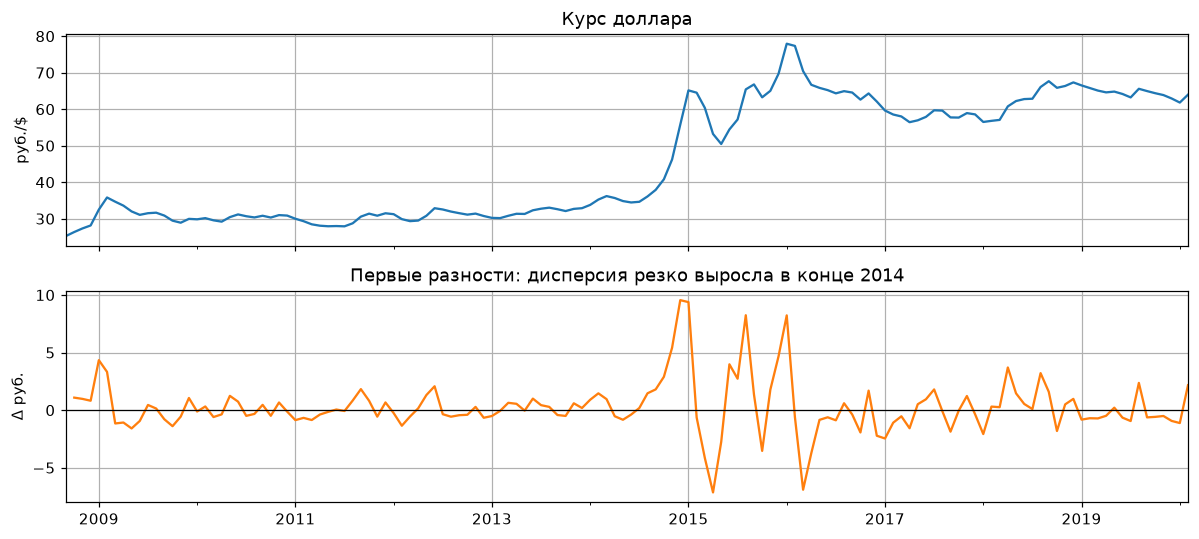

In [32]:
usd = idx_df["USD"]

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
usd.plot(ax=axes[0], color="C0")
axes[0].set(ylabel="руб./$", title="Курс доллара")
usd.diff().plot(ax=axes[1], color="C1")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(ylabel="Δ руб.", xlabel="", title="Первые разности: дисперсия резко выросла в конце 2014")
fig.tight_layout()

Строим три модели на одних и тех же данных:

1. ARIMA(1,1,0) — как есть;
2. ARIMA(1,1,0) + **импульсные дамми** на месяцы кризиса;
3. ARIMA(1,2,0) — «вылечим» сдвиг лишней разностью.

In [33]:
crisis = pd.DatetimeIndex(["2014-11-01", "2014-12-01", "2015-01-01", "2015-02-01"])
D_crisis = pd.DataFrame(
    {f"pulse_{d:%Y%m}": (usd.index == d).astype(float) for d in crisis}, index=usd.index
)

m_plain = SARIMAX(usd, order=(1, 1, 0)).fit(disp=False)
m_dummy = SARIMAX(usd, exog=D_crisis, order=(1, 1, 0)).fit(disp=False)
m_d2 = SARIMAX(usd, order=(1, 2, 0)).fit(disp=False)

Hu = 12
w = lambda r, **kw: float(np.diff(r.get_forecast(Hu, **kw).conf_int().iloc[-1])[0])

pd.DataFrame(
    {
        "σ̂²": [m_plain.params["sigma2"], m_dummy.params["sigma2"], m_d2.params["sigma2"]],
        "AIC": [m_plain.aic, m_dummy.aic, m_d2.aic],
        "ширина 95% PI при h=12": [
            w(m_plain),
            w(m_dummy, exog=np.zeros((Hu, D_crisis.shape[1]))),
            w(m_d2),
        ],
    },
    index=["ARIMA(1,1,0)", "ARIMA(1,1,0) + дамми на кризис", "ARIMA(1,2,0) — лишняя разность"],
).round(2)

,σ̂²,AIC,ширина 95% PI при h=12
"ARIMA(1,1,0)",3.99,582.48,49.41
"ARIMA(1,1,0) + дамми на кризис",3.47,571.38,42.09
"ARIMA(1,2,0) — лишняя разность",5.36,618.29,236.65


🔍 Читаем таблицу по столбцам.

* **$\hat\sigma^2$.** У модели с дамми она заметно меньше: четыре аномальных
  месяца больше не «размазаны» по оценке дисперсии всего ряда. А ведь именно
  $\hat\sigma^2$ задаёт ширину интервала для **всех** будущих точек — то есть
  один выброс в прошлом делал неопределёнными все прогнозы.
* **AIC.** Дамми стоят четыре параметра и всё равно окупаются.
* **Ширина PI.** У модели с лишней разностью интервал на 12 шагов заметно
  шире — та самая плата за $d = 2$.

🔍 И осторожность напоследок. Дамми на прошлые события — это **интерполяция**,
а не прогноз: мы объясняем то, что уже видели. Ставить дамми на каждый
неудобный месяц — прямой путь к переобучению. Разумный критерий: событие
должно иметь **содержательное объяснение** (кризис, смена методики, локдаун),
а не просто «здесь модель ошиблась».

А для прогноза важно другое: если событие может повториться, дамми на будущее
придётся ставить самим — и мы возвращаемся к способу 3, к сценариям.

---
# 8. Помогает ли регрессор вообще?

Мы разобрали, откуда взять `exog`. Остался вопрос, который логически идёт
первым: **а нужен ли он?**

Разберём это на сюжете про индексы настроений. Он показателен тем, что
«очевидно полезный» регрессор оказывается бесполезным — и понятно почему.

## 8.1. Методика

Единственный честный способ — **rolling-origin CV**: скользящее окно, на каждом
шаге переобучение и прогноз на 1 месяц вперёд, метрика по всем окнам. Никаких
`fittedvalues` и никакого `dynamic=False` (ноутбук `04`, раздел 4).

И обязательно — **бейзлайн**. Без него любое число бессмысленно: MAE = 150
млрд руб. — это хорошо или плохо? Для месячного ряда с годовой сезонностью
естественный бейзлайн — **сезонно-наивный прогноз**: «будет как в этом же
месяце год назад».

In [34]:
def seasonal_naive(y, s, m=12):
    """Прогноз на 1 шаг вперёд из точки s: значение m шагов назад."""
    return y.iloc[s - m]


def rolling_mae(y, X=None, order=ORDER, sorder=SORDER, n_test=36):
    """MAE одношаговых прогнозов на скользящем окне. X должен быть выровнен с y."""
    errs = []
    for s in range(len(y) - n_test, len(y)):
        if X is None:
            r = SARIMAX(y.iloc[:s], order=order, seasonal_order=sorder).fit(disp=False)
            pred = float(r.forecast(1).iloc[0])
        else:
            r = SARIMAX(y.iloc[:s], exog=X.iloc[:s], order=order, seasonal_order=sorder).fit(disp=False)
            pred = float(r.forecast(1, exog=X.iloc[s : s + 1]).iloc[0])
        errs.append(abs(pred - y.iloc[s]))
    return float(np.mean(errs))

## 8.2. Четыре варианта

⏱ **~15 с** (108 переобучений модели). Сравниваем на одном и том же отрезке
— последние 36 месяцев:

1. сезонно-наивный бейзлайн;
2. SARIMA без регрессоров;
3. SARIMA + **текущие** значения индексов ($x_t$);
4. SARIMA + **лагированные** значения ($x_{t-1}$).

Вариант 3 в реальном прогнозировании **невозможен**: чтобы дать модели $x_t$,
нужно знать индекс за тот самый месяц, который мы прогнозируем. Мы считаем его
специально — как измерение того, сколько информации о *настоящем* в индексе
вообще есть.

In [35]:
y_full = idx_df["RTRD"]

X_now = idx_df[["levada_IPN", "poiskInd_corr"]]
X_lag1 = idx_df[["levada_IPN", "poiskInd_corr"]].shift(1)
y_lag, X_lag1 = align(y_full, X_lag1)  # общий отрезок для лаговой версии

N_TEST = 36
base_err = [abs(seasonal_naive(y_full, s) - y_full.iloc[s]) for s in range(len(y_full) - N_TEST, len(y_full))]

res_cv = pd.DataFrame(
    {
        "MAE": [
            float(np.mean(base_err)),
            rolling_mae(y_full, None, n_test=N_TEST),
            rolling_mae(y_full, X_now, n_test=N_TEST),
            rolling_mae(y_lag, X_lag1, n_test=N_TEST),
        ]
    },
    index=[
        "бейзлайн: сезонно-наивный",
        "SARIMA без регрессоров",
        "SARIMA + индексы за текущий месяц (недоступно на практике)",
        "SARIMA + индексы за прошлый месяц (доступно)",
    ],
)
res_cv["в % от бейзлайна"] = 100 * res_cv["MAE"] / res_cv["MAE"].iloc[0]
res_cv["в % от SARIMA без X"] = 100 * res_cv["MAE"] / res_cv["MAE"].iloc[1]
res_cv.round(1)

,MAE,в % от бейзлайна,в % от SARIMA без X
бейзлайн: сезонно-наивный,152.0,100.0,806.8
SARIMA без регрессоров,18.8,12.4,100.0
SARIMA + индексы за текущий месяц (недоступно на практике),22.4,14.7,118.8
SARIMA + индексы за прошлый месяц (доступно),21.1,13.9,112.2


## 8.3. Вывод

В таблице три результата, и все три полезны.

**1. Бейзлайн проигрывает с огромным отрывом** — MAE 152 против 18.8, то есть
в восемь раз. Так бывает у ряда с сильным трендом: «будет как в этом же месяце
год назад» промахивается ровно на годовой прирост. Из этого не следует, что
бейзлайн не нужен, — наоборот: только теперь мы знаем, что модель действительно
что-то умеет, а не просто повторяет сезонный профиль.

**2. Регрессоры не помогли.** Обе версии с индексами оказались **хуже** модели
без них: 21.1 и 22.4 против 18.8. А ведь по AICc в разделе 6.3 лаг индекса
Левады выглядел улучшением на 6 единиц критерия.

Это кульминация, к которой мы шли с ноутбука `02`: **критерий — не метрика.**
AICc оценивает качество подгонки на всей выборке с поправкой на число
параметров. MAE на rolling-origin CV оценивает то, что нам нужно в реальности,
— ошибку прогноза на шаг вперёд при переобучении. Это разные величины, и они
не обязаны давать один ответ. Решение принимают **по метрике**, критерий нужен
только там, где отложенной выборки не хватает.

**3. Даже нечестная версия не помогла.** Модель с индексом за **текущий**
месяц знает то, чего в момент прогноза знать не может, — и всё равно
проигрывает базовой. Значит, дело даже не в лаге: в этих индексах нет
информации об обороте розничной торговли, которой не было бы уже в самой
истории оборота. Два лишних параметра есть, новой информации нет — отсюда и
ухудшение.

Исходный ноутбук `5.6`, на котором построен этот сюжет, формулирует вывод так:
**индексы настроений описывают настоящее, а не предсказывают будущее.** Они
измеряются опросом в том же месяце и отражают реакцию людей на уже
случившееся, то есть **синхронны** экономике, а не опережают её. Для прогноза
нужен опережающий индикатор — а таких мало, и они дороги.

🔍 **Общий алгоритм проверки полезности регрессора.** Он применим к любому
внешнему признаку:

1. Посчитайте бейзлайн (сезонно-наивный или наивный).
2. Посчитайте модель без регрессора — на rolling-origin CV.
3. Посчитайте модель с регрессором **в том виде, в каком он будет доступен в
   момент прогноза** (то есть с нужным лагом).
4. Сравните. Если выигрыш есть только у версии с $x_t$, а у версии с $x_{t-1}$
   его нет — регрессор объясняет настоящее, но не предсказывает будущее.
   В продакшн он не пойдёт.

Пункт 3 — тот, который пропускают чаще всего. Результат: модель, которая
блестяще работает в ноутбуке и разваливается на проде.

---
# 9. Подводные камни: чек-лист с кодом

## 9.1. Порядок столбцов важен, а имена — нет

In [36]:
Xc = idx_df[["levada_IPN", "poiskInd_corr"]]
m_c = SARIMAX(y_full.iloc[:-6], exog=Xc.iloc[:-6], order=(1, 1, 1)).fit(disp=False)

f_ok = m_c.forecast(6, exog=Xc.iloc[-6:])
f_swap = m_c.forecast(6, exog=Xc.iloc[-6:][["poiskInd_corr", "levada_IPN"]])  # переставили столбцы

pd.DataFrame({"правильный порядок": f_ok, "столбцы переставлены": f_swap,
              "разница": f_swap - f_ok}).round(1)

,правильный порядок,столбцы переставлены,разница
2019-09-01,2832.8,2982.6,149.8
2019-10-01,2793.2,2974.6,181.4
2019-11-01,2795.4,2984.1,188.7
2019-12-01,2799.8,3005.6,205.8
2020-01-01,2815.3,3030.2,214.9
2020-02-01,2811.7,2864.1,52.3


🔍 **Никакой ошибки не возникло.** `statsmodels` сопоставляет столбцы `exog`
**позиционно**, а не по именам: первый столбец умножается на первый $\beta$,
второй — на второй. Мы передали DataFrame с правильными именами, но в другом
порядке — и получили молча неверный прогноз.

Это самая коварная ошибка из всего списка, потому что она не падает и не
печатает предупреждения. Защита — держать список столбцов в переменной и
**всегда** индексировать им и обучающий, и прогнозный `exog`:

```python
FEATURES = ["levada_IPN", "poiskInd_corr"]
model = SARIMAX(y_tr, exog=X_tr[FEATURES], ...)
model.forecast(h, exog=X_te[FEATURES])
```

## 9.2. Константа в `exog` и `trend='c'` одновременно

In [37]:
try:
    SARIMAX(y_full, exog=Xc.assign(const=1.0), order=(1, 0, 0), trend="c").fit(disp=False)
except Exception as err:
    print(f"{type(err).__name__}: {err}")

ValueError: A constant trend was included in the model specification, but the `exog` data already contains a column of constants.


Здесь `statsmodels` защищается: столбец из единиц и константа тренда — это
одна и та же величина дважды, коэффициенты не определены однозначно.

А вот более коварная версия того же — **ловушка дамми-переменных**: полный
набор дамми по всем категориям в сумме даёт столбец единиц.

In [38]:
dow_full = pd.get_dummies(onion.index.dayofweek, prefix="d").astype(float)
dow_full.index = onion.index

print("сумма всех 7 дамми по строке:", dow_full.sum(axis=1).unique())

m_trap = SARIMAX(onion, exog=dow_full, order=(1, 0, 0), trend="c").fit(disp=False)
print(f"\nмодель обучилась без ошибок и предупреждений, llf = {m_trap.llf:.1f}")
print(f"intercept = {m_trap.params['intercept']:.1f}, дамми = "
      f"{m_trap.params[dow_full.columns].round(0).to_numpy()}")

сумма всех 7 дамми по строке: [1.]

модель обучилась без ошибок и предупреждений, llf = -11542.0
intercept = 76.6, дамми = [61394. 56402. 57475. 58380. 63297. 65071. 57604.]


Ошибки нет: проверка на точную константу не сработала, потому что **ни один
отдельный столбец** константой не является — константу даёт только их сумма.

Что при этом сломалось, видно не сразу. Возьмём найденные коэффициенты,
прибавим ко **всем** дамми одно и то же число $\delta$ и вычтем его из
константы. Если модель вырождена, правдоподобие не должно измениться вообще.

(Поправка на $1 - \hat\varphi_1$ — из ноутбука `04`, раздел 3.2: константа
`trend='c'` входит в уравнение для $n_t$, поэтому уровню ряда она добавляет
не $c$, а $c/(1-\hat\varphi_1)$.)

In [39]:
delta = 1000.0
shifted = m_trap.params.copy()
shifted.loc[dow_full.columns] += delta
shifted.loc["intercept"] -= delta * (1 - m_trap.params["ar.L1"])

llf_0 = m_trap.model.loglike(m_trap.params.to_numpy())
llf_1 = m_trap.model.loglike(shifted.to_numpy())
print(f"logL при найденных коэффициентах : {llf_0:.8f}")
print(f"logL после сдвига всех дамми на {delta:.0f}: {llf_1:.8f}")
print(f"разница                          : {llf_1 - llf_0:.1e}")

fc_0 = m_trap.forecast(7, exog=dow_full.iloc[:7])
fc_1 = m_trap.model.smooth(shifted.to_numpy()).forecast(7, exog=dow_full.iloc[:7])
print(f"\nмакс. расхождение прогнозов на 7 дней: {np.abs(fc_0 - fc_1).max():.1e}")

logL при найденных коэффициентах : -11541.96975357
logL после сдвига всех дамми на 1000: -11541.96975357
разница                          : 1.8e-12

макс. расхождение прогнозов на 7 дней: 1.5e-11


🔍 **Вот в чём проблема.** Правдоподобие не изменилось (разница $10^{-12}$ —
машинная точность), прогнозы не изменились. То есть **бесконечно много разных
наборов коэффициентов описывают данные одинаково хорошо**, и оптимизатор
вернул один из них произвольно.

Следствия:

* **Коэффициенты нельзя интерпретировать.** «Спрос в среду 57 475» — это не
  факт о данных, а артефакт того, где остановился `lbfgs`. Сдвинь всё на
  тысячу — модель та же.
* **Стандартные ошибки и p-value бессмысленны:** они посчитаны по гессиану,
  который в вырожденном направлении плоский.
* **Прогноз при этом корректный.** Именно поэтому ошибку легко не заметить:
  графики хорошие, метрики хорошие, а таблица коэффициентов — мусор.

Лечится одной строкой: убрать вторую константу.

In [40]:
m_fix = SARIMAX(onion, exog=dow_full, order=(1, 0, 0), trend="n").fit(disp=False)

print(f"llf: {m_fix.llf:.1f}   (у вырожденной модели было {m_trap.llf:.1f})")

days = ["Пн", "Вт", "Ср", "Чт", "Пт", "Сб", "Вс"]
pd.DataFrame(
    {
        "уровень, руб.": m_fix.params[dow_full.columns].to_numpy(),
        "станд. ошибка": m_fix.bse[dow_full.columns].to_numpy(),
    },
    index=days,
).round(0)

llf: -11541.9   (у вырожденной модели было -11542.0)


,"уровень, руб.",станд. ошибка
Пн,61394.0,4707.0
Вт,56402.0,4607.0
Ср,57475.0,4532.0
Чт,58380.0,4621.0
Пт,63297.0,4668.0
Сб,65071.0,4734.0
Вс,57604.0,4746.0


Правдоподобие то же самое — подгонка не изменилась, — но теперь решение
единственное, и коэффициенты читаются буквально: это средний уровень продаж
по дням недели. Видно, что суббота — самый сильный день, вторник — самый
слабый.

**Правило.** При кодировании категории с $c$ уровнями возможны два корректных
варианта:

* все $c$ дамми, но **без** константы (`trend='n'`) — коэффициенты читаются
  как уровни;
* $c-1$ дамми **с** константой — коэффициенты читаются как отклонения от
  базовой категории (так устроена наша `calendar_features`).

Чего нельзя — брать все $c$ дамми **и** константу.

🔍 Небольшая практическая заметка к первому варианту. На этом ряду `trend='n'`
с полным набором дамми не только корректнее, но и просто удобнее для
оптимизатора: в варианте «$c-1$ дамми + константа» константе приходится
в одиночку тянуть уровень порядка 60 000, да ещё и через делитель
$1-\hat\varphi_1$, и `lbfgs` с дефолтными стартовыми значениями сходится к
нему заметно хуже. Это ровно та проблема плохой обусловленности, о которой
следующий раздел.

## 9.3. Масштаб регрессоров

Оптимизатор `lbfgs` работает с параметрами в их естественном масштабе. Если
регрессор измеряется миллионами, то $\beta$ при нём будет порядка $10^{-6}$, и
критерий остановки сработает раньше, чем оптимизация действительно сойдётся.

In [41]:
X_small = idx_df[["levada_IPN"]]
X_huge = X_small * 1e6  # тот же признак в других единицах

m_small = SARIMAX(y_full, exog=X_small, order=(1, 1, 1)).fit(disp=False)
m_huge = SARIMAX(y_full, exog=X_huge, order=(1, 1, 1)).fit(disp=False)

pd.DataFrame(
    {
        "logL": [m_small.llf, m_huge.llf],
        "итераций оптимизатора": [m_small.mle_retvals["iterations"], m_huge.mle_retvals["iterations"]],
        "β": [m_small.params.iloc[-2], m_huge.params.iloc[-2]],
    },
    index=["нормальный масштаб", "умножено на 10⁶"],
)

,logL,итераций оптимизатора,β
нормальный масштаб,-919.826003,24,-0.770564
умножено на 10⁶,-920.766526,2,-0.783698


🔍 Модель в «неудобных» единицах остановилась почти сразу и нашла **худшее**
правдоподобие. Математически это одна и та же модель — отличается только
единица измерения, — но численно результаты разные.

**Правило.** Приводите регрессоры к сопоставимому масштабу (порядка единиц —
десятков) до передачи в `SARIMAX`. Стандартизация или простой перевод единиц
(рубли → млрд руб.) решают проблему. Целевой ряд, кстати, тоже: если $y$
измеряется в единицах $10^9$, `sigma2` будет $10^{18}$, и оптимизатору так же
неудобно.

## 9.4. Утечка: главный риск

Утечка — это любое значение $x_t$, которое в реальности станет известно
**позже** момента прогноза. Формально столбец есть, метрика отличная, в
продакшне модель не работает.

Типичные источники:

| Что | Почему утечка |
|---|---|
| Данные, публикуемые с задержкой (Росстат, отчётность) | значение за март доступно в мае |
| Данные, которые ретроспективно пересматриваются | в истории лежит уточнённая версия, в реальном времени была предварительная |
| Агрегаты, посчитанные по всей выборке (среднее, стандартизация) | в них зашита информация из будущего |
| Признаки от самого $y$ без лага (`rolling().mean()` без `shift`) | окно включает текущую точку |

Проверочный вопрос ровно один:

> **«В момент времени $T$, когда я строю прогноз на $T+h$, будет ли это
> значение уже у меня на руках?»**

Если ответ «нет» или «не уверен» — берите лаг с запасом (способ 5). Раздел 8
показал, чем это отличается: колонка «недоступно на практике» существует именно
для того, чтобы увидеть цену утечки в числах.

---
# Итоги

## Шесть способов ещё раз — с честной оценкой

| Способ | Когда применим | Что помнить |
|---|---|---|
| 1. Детерминированные | всегда, когда признак — функция даты | паттерн «удлинить → посчитать → разрезать»; `DeterministicProcess` |
| 1а. Фурье вместо сезонной части | $m$ большой; несколько сезонностей | здесь оказалась в 500 раз быстрее; $K$ по AICc, $K \le m/2$ |
| 2. По плану / контракту | праздники, промо, тарифы | вклад измеряется сравнением двух прогнозов |
| 3. Сценарные | регрессор неизвестен, но диапазон понятен | это **условный** прогноз; показывать веером |
| 4. Прогноз регрессора | $x$ прогнозируется лучше, чем $y$ | интервал занижен; расширять симуляцией |
| 5. Лаговые | есть содержательный лаг $k \ge h$ | будущее известно бесплатно |
| 6. Дамми | размеченные события и сдвиги | сдвиг лечится дамми, а не разностью |

## Что нужно унести

1. **Признаки, зависящие только от даты, считаются один раз на удлинённом
   индексе.** Два отдельных вычисления для истории и будущего — источник
   рассинхронизации, которую никто не заметит.

2. **Гармоники Фурье — главный практический ответ на «SARIMA долго учится».**
   Замена $(1,0,0)_{365}$ на 12 гармоник в `exog` дала здесь ускорение
   в 500 раз — **и при этом лучший AIC**. Попутно появляется то, чего SARIMA
   не умеет в принципе: **несколько сезонностей сразу**.

3. **Разница двух прогнозов, отличающихся одним регрессором, — это измеренный
   вклад этого регрессора**, в единицах $y$. Показывать заказчику нужно именно
   это число, а не p-value.

4. **Прогноз с придуманным `exog` — условный прогноз.** Показывайте веером из
   нескольких сценариев и подписывайте допущение.

5. **Неопределённость спрогнозированного регрессора в интервал не входит.**
   Аналитический PI при способе 4 систематически занижен; честная оценка —
   симуляция траекторий $x$.

6. **Лаг $k \ge h$ снимает проблему целиком.** Если модель работает на
   $x_{t-k}$, будущее регрессора известно бесплатно и точно.

7. **Полезность регрессора проверяется на rolling-origin CV, с бейзлайном и с
   тем лагом, который реально будет доступен.** По AICc лаг индекса Левады
   выглядел улучшением на 6 единиц; на CV та же модель оказалась **хуже**
   модели без регрессоров. Критерий — не метрика; решение принимают по метрике.

8. **Сравнивая модели по AIC/AICc/BIC, проверяйте `nobs`.** Лаги и `dropna()`
   незаметно укорачивают выборку, и критерий начинает сравнивать не
   спецификации, а выборки: в разделе 6.3 из-за этого «победителем» оказался
   худший из пяти наборов регрессоров.

8. **Столбцы `exog` матчатся позиционно.** Держите список признаков в
   переменной и индексируйте им обе выборки.

## Чек-лист «я добавил регрессор в SARIMAX»

1. Откуда будет взято $x_{T+h}$? Назовите способ из таблицы — если не можете,
   регрессор брать рано.
2. Если это способ 3 или 4 — сказано ли в подписи к графику, что прогноз
   условный или что интервал занижен?
3. Все ли значения $x_t$ будут известны в момент прогноза? Нет ли утечки?
4. Столбцы в `fit` и в `forecast` идут в одном порядке?
5. Нет ли константы дважды (`trend='c'` + полный набор дамми)?
6. Регрессоры в разумном масштабе?
7. Есть ли бейзлайн и измерен ли выигрыш на CV, а не на обучающей выборке?

---

**Дальше:** ноутбук `06` — три сквозных кейса по единому чек-листу, от EDA до
вывода в бизнес-терминах. Всё, что мы разбирали по частям, там применяется
целиком.